In [3]:
from IPython.display import display, SVG

from geonss import spp
from geonss.constellation import select_constellations
from geonss.coordinates import ECEFPosition, LLAPosition
from geonss.parsing import load_cached
from geonss.plotting import plot_positions_in_latlon, plot_altitude_differences
from geonss.util import get_project_output
from geonss.util import print_distance_information
from tests.util import path_test_file

In [11]:
observation = load_cached(path_test_file("WTZR00DEU_R_20250980000_01D_30S_MO.crx"))
navigation = load_cached(path_test_file("BRDC00IGS_R_20250980000_01D_MN.rnx"))
# navigation = load_cached(path_test_file("WTZR00DEU_R_20250980000_01D_MN.rnx"))

observation = select_constellations(observation, galileo=True)
navigation = select_constellations(navigation, galileo=True)

observation = observation.sel(time=slice("2025-04-08T06:00:00", "2025-04-08T09:00:00"))

In [12]:
true = ECEFPosition.from_tuple(observation.attrs["position"])
true_lla = true.to_lla()

# No Correction

In [13]:
result_no = spp(observation, navigation,
                enable_signal_travel_time_correction = False,
                enable_earth_rotation_correction = False,
                enable_tropospheric_correction = False,
                enable_elevation_weighting = False,
                enable_snr_weighting = False,
               )

In [14]:
computed_no = [ECEFPosition.from_array(pos) for pos in result_no.squeeze().position.values * 1000.0]
computed_no_lla = [pos.to_lla() for pos in computed_no]

In [15]:
print_distance_information(true, computed_no)


    Distance Information:
    | Metric         | Distance (m)   | Horizontal (m) | Altitude (m)   |
    |----------------|----------------|----------------|----------------|
    | Mean           |     6997385.95 |     6996655.61 |           2.28 |
    | Std. Deviation |      513310.70 |      513259.46 |          20.37 |
    | Max            |     7788557.82 |     7787736.34 |          53.07 |
    


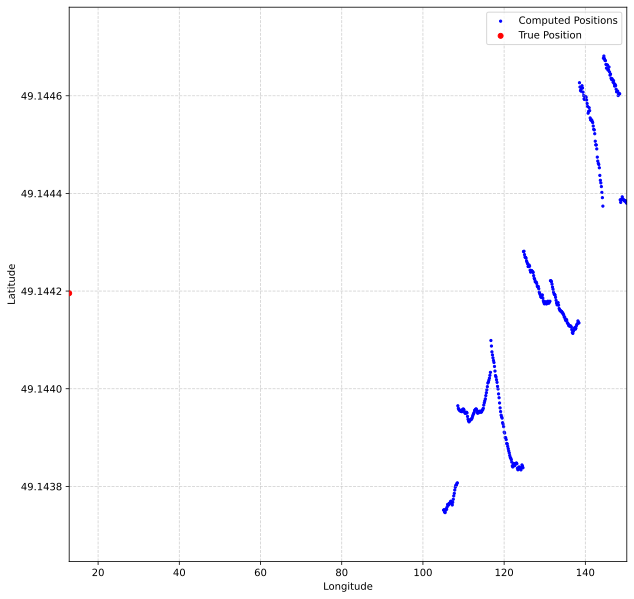

In [16]:
plot_path_no_0 = plot_positions_in_latlon(true_lla, computed_no_lla, filename=(get_project_output() / "latlon_no.svg"))
display(SVG(plot_path_no_0))

# plot_path_no_1 = plot_altitude_differences(true_lla, computed_no_lla, filename=(get_project_output() / "altitude.svg"))
# display(SVG(plot_path_no_1))

# Earth Rotation Correction

In [8]:
result_rotation = spp(observation, navigation,
                      enable_signal_travel_time_correction = False,
                      enable_earth_rotation_correction = True,
                      enable_tropospheric_correction = False,
                      enable_elevation_weighting = False,
                      enable_snr_weighting = False,
                     )

In [9]:
computed_rotation = [ECEFPosition.from_array(pos) for pos in result_rotation.squeeze().position.values * 1000.0]
computed_rotation_lla = [pos.to_lla() for pos in computed_rotation]


In [10]:
print_distance_information(true, computed_rotation)


    Distance Information:
    | Metric         | Distance (m)   | Horizontal (m) | Altitude (m)   |
    |----------------|----------------|----------------|----------------|
    | Mean           |          36.79 |          28.42 |           2.16 |
    | Std. Deviation |          12.71 |          16.77 |          20.51 |
    | Max            |          64.78 |          59.46 |          52.23 |
    


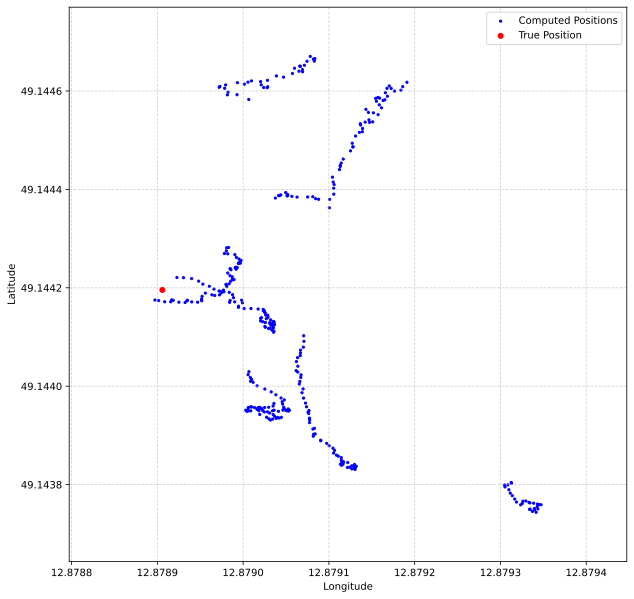

In [11]:
plot_path_rotation_0 = plot_positions_in_latlon(true_lla, computed_rotation_lla, filename=(get_project_output() / "latlon_rotation.svg"))
display(SVG(plot_path_rotation_0))

#plot_path_rotation_1 = plot_altitude_differences(true_lla, computed_rotation_lla, filename=(get_project_output() / "altitude_rotation.svg"))
# display(SVG(#plot_path_rotation_1))

# Travel Time Correction

In [12]:
result_travel = spp(observation, navigation,
                    enable_signal_travel_time_correction=True,
                    enable_earth_rotation_correction=True,
                    enable_tropospheric_correction=False,
                    enable_elevation_weighting=False,
                    enable_snr_weighting=False,
                   )

In [13]:
computed_travel = [ECEFPosition.from_array(pos) for pos in result_travel.squeeze().position.values * 1000.0]
computed_travel_lla = [pos.to_lla() for pos in computed_travel]

In [14]:
print_distance_information(true, computed_travel)


    Distance Information:
    | Metric         | Distance (m)   | Horizontal (m) | Altitude (m)   |
    |----------------|----------------|----------------|----------------|
    | Mean           |          12.16 |           1.66 |          12.02 |
    | Std. Deviation |           4.66 |           0.95 |           4.63 |
    | Max            |          27.03 |           4.82 |          26.84 |
    


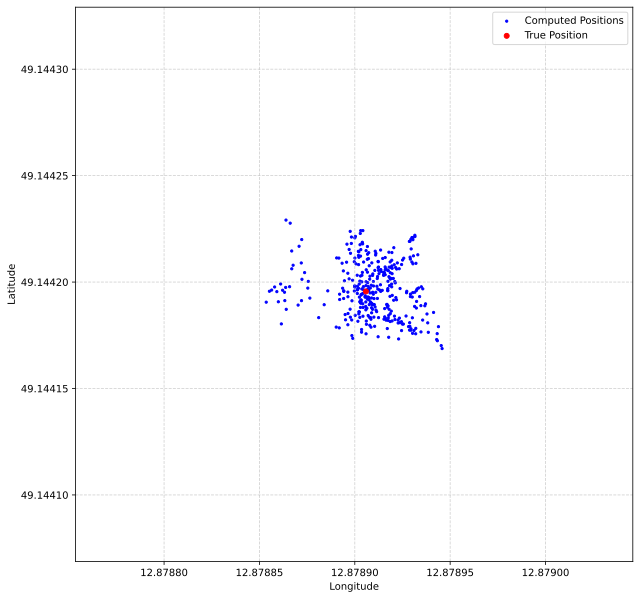

In [15]:
plot_path_travel_0 = plot_positions_in_latlon(true_lla, computed_travel_lla, filename=(get_project_output() / "latlon_travel.svg"))
display(SVG(plot_path_travel_0))

# plot_path_travel_1 = plot_altitude_differences(true_lla, computed_lla, filename=(get_project_output() / "altitude_travel.svg"))
# display(SVG(plot_path_travel_1))

# Troposphere Correction

In [16]:
result_tropo = spp(observation, navigation,
                   enable_signal_travel_time_correction=True,
                   enable_earth_rotation_correction=True,
                   enable_tropospheric_correction=True,
                   enable_elevation_weighting=False,
                   enable_snr_weighting=False,
                  )

In [17]:
computed_tropo = [ECEFPosition.from_array(pos) for pos in result_tropo.squeeze().position.values * 1000.0]
computed_tropo_lla = [pos.to_lla() for pos in computed_tropo]

In [18]:
print_distance_information(true, computed_tropo)


    Distance Information:
    | Metric         | Distance (m)   | Horizontal (m) | Altitude (m)   |
    |----------------|----------------|----------------|----------------|
    | Mean           |           1.44 |           0.85 |          -0.72 |
    | Std. Deviation |           0.59 |           0.44 |           0.98 |
    | Max            |           3.43 |           2.56 |           3.12 |
    


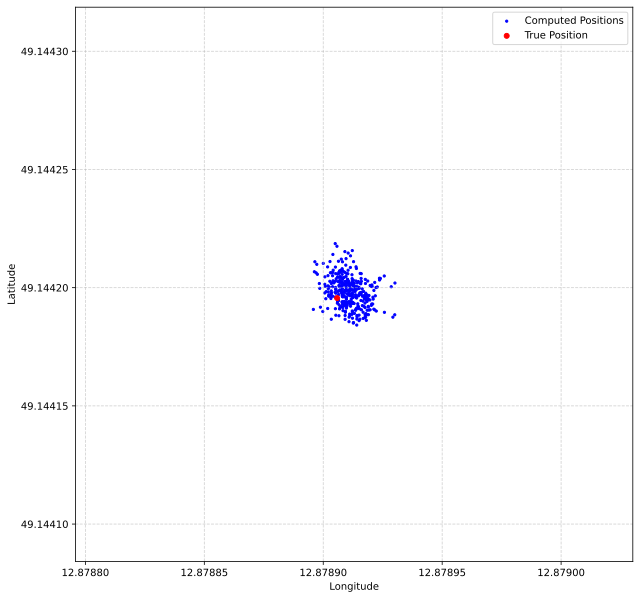

In [19]:
plot_path_tropo_0 = plot_positions_in_latlon(true_lla, computed_tropo_lla, filename=(get_project_output() / "latlon_tropo.svg"))
display(SVG(plot_path_tropo_0))

# plot_path_tropo_1 = plot_altitude_differences(true_lla, computed_lla, filename=(get_project_output() / "altitude_tropo.svg"))
# display(SVG(plot_path_tropo_1))

# Elevation and SNR Weighting

In [20]:
result_all = spp(observation, navigation,
                 enable_signal_travel_time_correction=True,
                 enable_earth_rotation_correction=True,
                 enable_tropospheric_correction=True,
                 enable_elevation_weighting=True,
                 enable_snr_weighting=True,
                )

In [21]:
computed_all = [ECEFPosition.from_array(pos) for pos in result_all.squeeze().position.values * 1000.0]
computed_all_lla = [pos.to_lla() for pos in computed_all]

In [22]:
print_distance_information(true, computed_all)


    Distance Information:
    | Metric         | Distance (m)   | Horizontal (m) | Altitude (m)   |
    |----------------|----------------|----------------|----------------|
    | Mean           |           1.42 |           0.87 |          -0.07 |
    | Std. Deviation |           0.73 |           0.49 |           1.25 |
    | Max            |           3.77 |           2.41 |           3.40 |
    


In [23]:
import numpy as np
np.mean(computed_all_lla)

TypeError: unsupported operand type(s) for +: 'LLAPosition' and 'LLAPosition'

In [ ]:
plot_path_all_0 = plot_positions_in_latlon(true_lla, computed_all_lla, filename=(get_project_output() / "latlon_all.svg"))
display(SVG(plot_path_all_0))

# plot_path_all_1 = plot_altitude_differences(true_lla, computed_all_lla, filename=(get_project_output() / "altitude_all.svg"))
# display(SVG(plot_path_all_1))